# Preparing Data and Coding Environment

## Importing libraries

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


## Fetching data

We will work on a dataset fetched from Kaggle.com which is based on `California Housing Data` `Pace, R. Kelley, and Ronald Barry. "Sparse spatial autoregressions." Statistics & Probability Letters 33.3 (1997): 291-297.` 

Author modified it a little and enriched it with 5 variables - `Distance_to_coast` and distances to the centre of the largest cities in California.

In [11]:
df = pd.read_csv("California_Houses.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


Before we dive into the exploratory data analysis and train our machine learning models, it is crucial to clarify exactly what our data represents. A common pitfall when looking at this dataset is assuming that each row corresponds to a single, specific house. This is not the case.

Due to privacy protocols in the US Census, data is aggregated into geographic areas called block groups (or simply "blocks"). A block typically contains between 600 and 3,000 people. Therefore, every row in our dataset represents the aggregate statistics for an entire neighborhood, not an individual property or family.

## EDA

In [12]:
df.isna().sum()

Median_House_Value          0
Median_Income               0
Median_Age                  0
Tot_Rooms                   0
Tot_Bedrooms                0
Population                  0
Households                  0
Latitude                    0
Longitude                   0
Distance_to_coast           0
Distance_to_LA              0
Distance_to_SanDiego        0
Distance_to_SanJose         0
Distance_to_SanFrancisco    0
dtype: int64

In [13]:
df.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


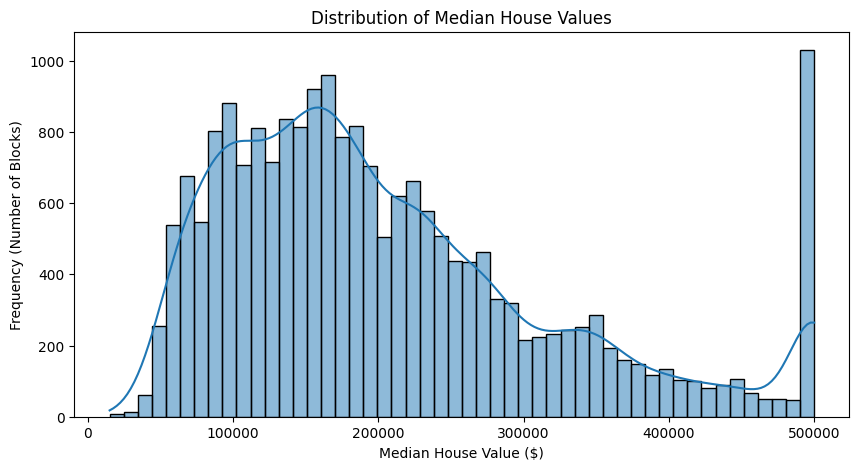

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Median_House_Value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency (Number of Blocks)')
plt.show()

Looking at the far right of the histogram, there is a massive, unnatural spike exactly at the $500,001 mark.

This isn't a coincidence. During the original census, any neighborhood with a median value higher than half a million dollars was artificially capped at $500,001. This means a standard family home on the coast and a massive Hollywood mansion were lumped into the exact same "data bucket" and given the exact same price tag.

If we feed this capped data to our machine learning models, it will deeply confuse them. The algorithms will struggle to learn the mathematical rules of the market if vastly different properties are artificially priced the same.

As this research is mostly focused on applying ML algorithms, to fix this, we will simply drop households above 500,000$.

In [34]:
df_clean = df[df['Median_House_Value'] < 500001].copy()

dropped_rows = df.shape[0] - df_clean.shape[0]
dropped_rows

965

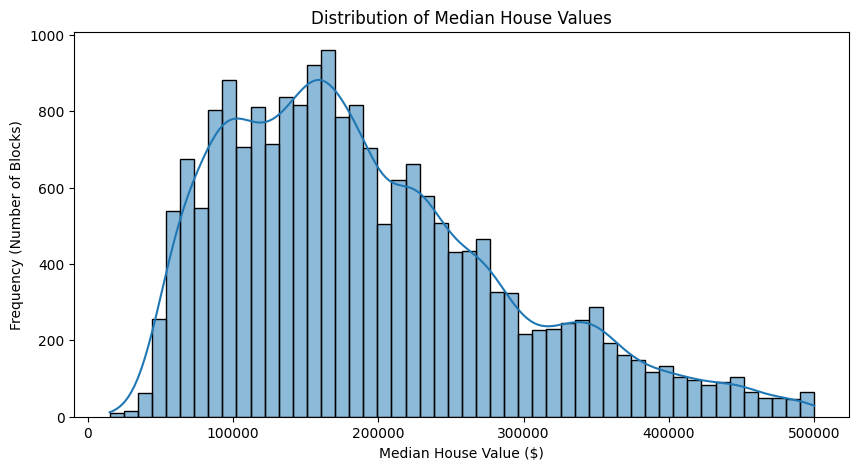

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Median_House_Value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency (Number of Blocks)')
plt.show()

Now target value looks much "healthier".


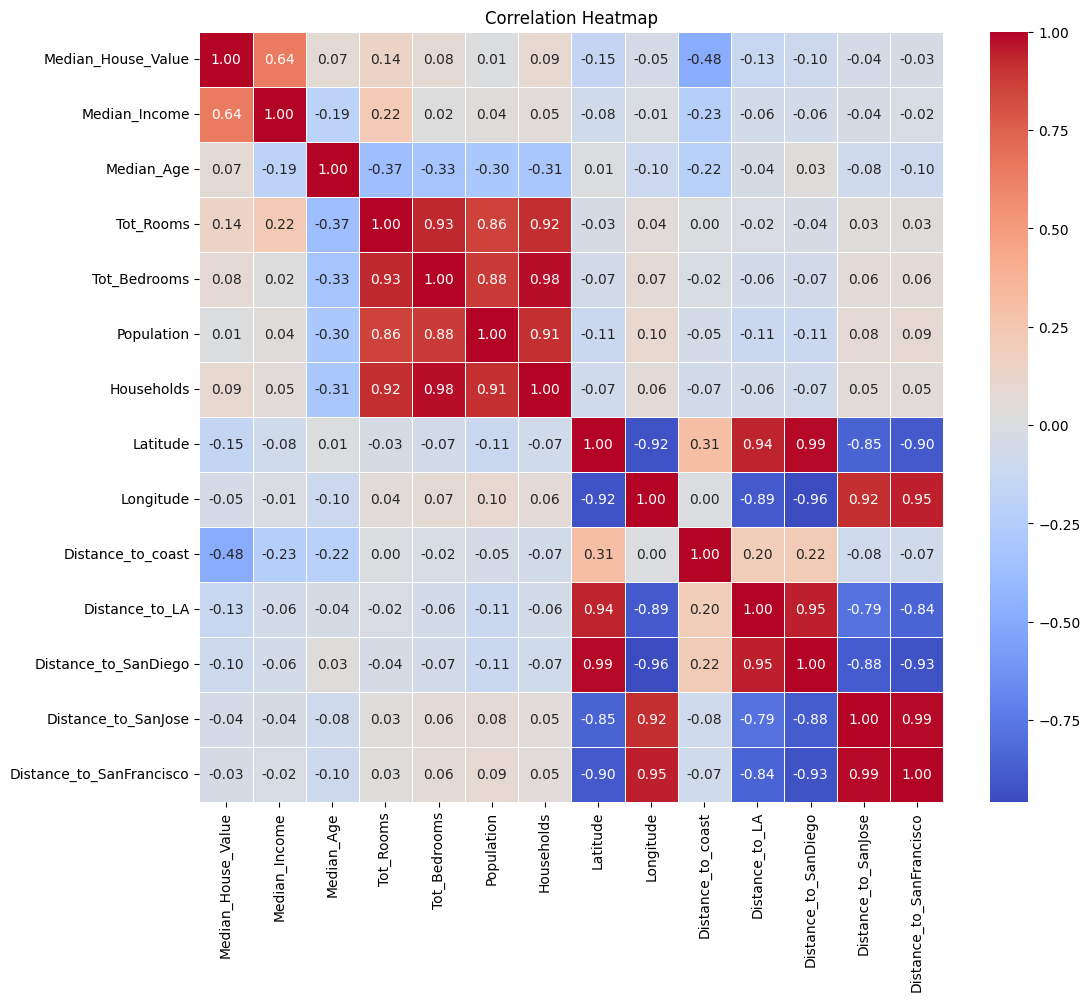

In [37]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [26]:
correlations_with_price = correlation_matrix['Median_House_Value'].sort_values(ascending=False)
correlations_with_price

Median_House_Value          1.000000
Median_Income               0.688075
Tot_Rooms                   0.134153
Median_Age                  0.105623
Households                  0.065843
Tot_Bedrooms                0.050594
Population                 -0.024650
Distance_to_SanFrancisco   -0.030559
Distance_to_SanJose        -0.041590
Longitude                  -0.045967
Distance_to_SanDiego       -0.092510
Distance_to_LA             -0.130678
Latitude                   -0.144160
Distance_to_coast          -0.469350
Name: Median_House_Value, dtype: float64

# Random Forest Regressor

### Stage 1


How it works: A single decision tree can easily make mistakes. Random forests create an entire army of them (e.g., 100 trees). Each tree gets a slightly different, random subset of car data and a random set of columns to work with. In the end, all the trees vote on the final price. This drastically reduces the errors of a single tree (the wisdom of the crowd).

Because Random Forests don't need scaled data, we are going to train it on the raw, unscaled X_train. This is a huge advantage because later on, when we look at the results, the numbers will still be in real-world units (meters, dollars, years) instead of confusing standardized decimals!

In [41]:
print("--- STAGE 0: SPLITTING THE DATA ---")

# 1. Define what we are trying to predict (y) and the data we use to predict it (X)
y = df_clean['Median_House_Value']
X = df_clean.drop(columns=['Median_House_Value'])

# 2. The Golden Split
# test_size=0.2 means 20% of the neighborhoods are locked away for the "Final Exam"
# random_state=42 ensures the data is shuffled the exact same way every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")
print(f"Training data (The Textbook): {X_train.shape[0]} blocks")
print(f"Testing data (The Final Exam):  {X_test.shape[0]} blocks")

--- STAGE 0: SPLITTING THE DATA ---
Data successfully split!
Training data (The Textbook): 15740 blocks
Testing data (The Final Exam):  3935 blocks


### Stage 2 Training

How it works: A single Decision Tree is like a single real estate agent—they might be biased or memorize a few specific neighborhoods. A Random Forest is an ensemble of, say, 100 different agents.

Bootstrapping: The algorithm gives each of the 100 trees a slightly different, random slice of your dataset to learn from.

Feature Randomness: When a tree tries to make a decision, it isn't allowed to look at all 14 features. It's only allowed to look at a random subset (maybe just 4 of them).

The Result: This forces the trees to be very diverse. Some trees become experts on "Distance to the Coast," while others become experts on "House Age."

Why we do this: By combining hundreds of diverse, slightly imperfect trees, the overall forest becomes incredibly accurate and highly resistant to overfitting (memorizing the training data).

Key parameters:

n_estimators: The number of trees in the forest (the more, the more stable the model, but the slower it trains).

n_jobs: Setting this to -1 forces your processor to work on all cores, drastically speeding up the process.

In [42]:
# n_estimators: How many trees in our forest? (100 is a great starting point)
# random_state: Ensures we get the exact same results every time we run the code
# n_jobs=-1: Tells your computer to use all CPU cores to train faster!

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Notice we are passing the raw X_train, NOT X_train_scaled!
print("Planting 100 decision trees and learning the California market...")
rf_model.fit(X_train, y_train)
print("Training complete! The Forest is ready.")

Planting 100 decision trees and learning the California market...
Training complete! The Forest is ready.


### Stage 3 Making Predictions & Evaluating

Now we take our X_test data (the 20% of neighborhoods the model has never seen) and ask it for a price.The data for one neighborhood is passed to all 100 trees. Tree #1 predicts $200,000. Tree #2 predicts $215,000. Tree #100 predicts $195,000. The Random Forest takes the average of all 100 predictions and presents that as the final answer.Why we do this: We need to measure how wrong the model is on average. We will use MAE (Mean Absolute Error), which tells us exactly how many dollars we are off by. We will also use $R^2$ (R-squared), which is a percentage (from 0 to 1) of how perfectly our model caught the "vibe" and logic of the housing market

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

print("--- 2. EVALUATING THE MODEL ---")
# Ask the model to predict prices for the unseen test set
rf_predictions = rf_model.predict(X_test)

# Calculate the errors
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"This means our model's valuation is off by an average of ${mae:,.0f} per neighborhood.")
print(f"R-squared Score: {r2:.4f} (1.0 is a perfect score)")

--- 2. EVALUATING THE MODEL ---
Mean Absolute Error (MAE): $29,154
This means our model's valuation is off by an average of $29,154 per neighborhood.
R-squared Score: 0.8030 (1.0 is a perfect score)


### Diving into the black box

How it works: One of the greatest things about Random Forests is that they aren't totally opaque. Because the algorithm had to split the data millions of times across 100 trees, it kept a tally. It knows exactly which features (like Income or Distance to LA) resulted in the biggest, most mathematically pure splits in the data.

--- 3. FEATURE IMPORTANCE ---


C:\Users\jakub\AppData\Local\Temp\ipykernel_12284\1376196476.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


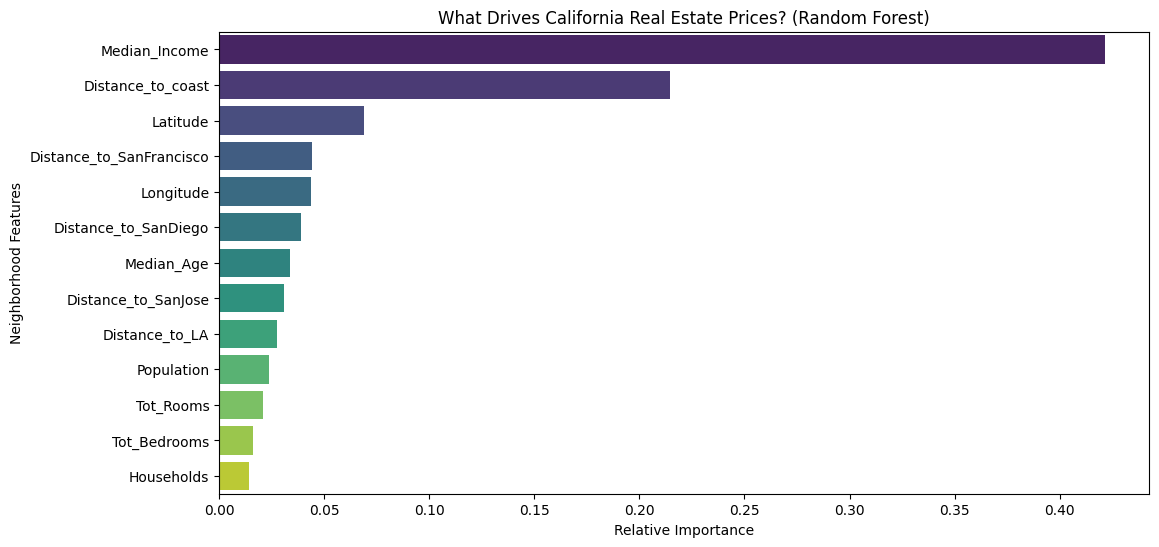

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3. FEATURE IMPORTANCE ---")
# Extract the importance values from the trained model
importances = rf_model.feature_importances_

# Bind them to the column names for readability
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('What Drives California Real Estate Prices? (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Neighborhood Features')
plt.show()

## Can we improve it?

We will use Grid Search combined with K-fold cross-validation to find the most suitable parameters

For every single combination of settings, K-Fold chops X_train data into 5 pieces. It trains the forest on 4 pieces and tests it on the 5th. It does this 5 times, rotating the test piece, and takes the average score, which reduces the variance. This proves that the forest didn't just get lucky—it is genuinely good.

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

print("--- GRID SEARCH & CROSS VALIDATION ---")

# 1. Define the "Menu" of settings to test
# n_estimators: Number of trees
# max_depth: How deep the trees can grow (None means they grow until they are pure)
# min_samples_split: Minimum number of houses required to split a node further
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. Initialize the base model
rf_base = RandomForestRegressor(random_state=42)

# 3. Set up the Grid Search
# cv=5 means 5-fold cross-validation (5 practice exams per combination)
# n_jobs=-1 uses all your CPU cores
# scoring='neg_mean_absolute_error' tells it to look for the lowest dollar error
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5, 
    n_jobs=-1, 
    scoring='neg_mean_absolute_error',
    verbose=2 # This prints out updates so you don't think your computer froze
)

print("Starting the Grid Search... this might take a minute or two!")
# 4. Run the grueling tests on the training data ONLY
grid_search.fit(X_train, y_train)

# 5. The Results
print("\n--- RESULTS ---")
print("Best Settings Found:")
print(grid_search.best_params_)

# Extract the absolute best model from the search
best_rf_model = grid_search.best_estimator_

--- GRID SEARCH & CROSS VALIDATION ---
Starting the Grid Search... this might take a minute or two!
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- RESULTS ---
Best Settings Found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("--- THE FINAL EXAM: TESTING THE OPTIMIZED MODEL ---")

# 1. Ask the optimized model to predict prices for the unseen Test set
# Note: 'best_rf_model' was saved automatically in the previous Grid Search cell!
final_predictions = best_rf_model.predict(X_test)

# 2. Calculate the metrics by comparing predictions to the actual hidden prices (y_test)
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
r2 = r2_score(y_test, final_predictions)

# 3. Print the official final report
print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.0f}")
print(f"R-squared (R^2) Score: {r2:.4f} / 1.0000")

--- THE FINAL EXAM: TESTING THE OPTIMIZED MODEL ---
Mean Absolute Error (MAE): $29,069
Root Mean Squared Error (RMSE): $44,245
R-squared (R^2) Score: 0.8037 / 1.0000


There were only a small decrease in MAE, so small, we qualify it as a noise. 

Therefore, we will try more complex feature engineering.

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("--- FEATURE ENGINEERING: LEVELING UP THE DATA ---")

# 1. Create a fresh copy of our clean data
df_engineered = df_clean.copy()

# 2. Engineer the new, highly predictive ratios using your exact column names
df_engineered['Rooms_per_Household'] = df_engineered['Tot_Rooms'] / df_engineered['Households']
df_engineered['Bedrooms_per_Room'] = df_engineered['Tot_Bedrooms'] / df_engineered['Tot_Rooms']
df_engineered['Population_per_Household'] = df_engineered['Population'] / df_engineered['Households']

# 3. Drop the old absolute totals that were confusing the model
columns_to_drop = ['Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households']
df_engineered = df_engineered.drop(columns=columns_to_drop)

print("New features created! Old 'Tot_' and absolute columns dropped.")

# --- QUICK RETRAIN TO TEST THE THEORY ---
# Smart check: ensuring we use the right name for the target column whether it has underscores or spaces
target_col = 'Median_House_Value' if 'Median_House_Value' in df_engineered.columns else 'Median House Value'

# Split the new engineered data
y_eng = df_engineered[target_col]
X_eng = df_engineered.drop(columns=[target_col])

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

# Train using your optimal settings from the Grid Search
print("Training the optimized Forest on the newly engineered data...")
rf_eng = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1)
rf_eng.fit(X_train_eng, y_train_eng)

# Evaluate
eng_preds = rf_eng.predict(X_test_eng)
new_mae = mean_absolute_error(y_test_eng, eng_preds)

print(f"\n--- THE RESULTS ---")
print(f"Old Best MAE: $29,069")
print(f"New Engineered MAE: ${new_mae:,.0f}")

--- FEATURE ENGINEERING: LEVELING UP THE DATA ---
New features created! Old 'Tot_' and absolute columns dropped.
Training the optimized Forest on the newly engineered data...

--- THE RESULTS ---
Old Best MAE: $29,069
New Engineered MAE: $28,287


Trash in trash out as they say. We were able to reduce MAE by 800$ just by simple division.

# Gradient Boosting Regressor

How it works: This is the reigning champion of tabular data. It works sequentially. It builds the first, very simple little tree. Then, it looks at which cars this tree made the biggest mistakes on. The second tree learns only from the mistakes of the first one. The third fixes the mistakes of the second, and so on. This creates a killer, self-correcting team.

The Key Parameters
n_estimators: The number of correction stages (trees).

learning_rate: How heavily we weight the corrections of each new tree. A smaller learning rate (like 0.1) prevents the model from overcorrecting and going crazy, but it means you need more trees to reach the final answer.

max_depth: Unlike Random Forests which use massive, infinitely deep trees, Gradient Boosting uses very shallow trees (usually a depth of 3 to 5). It relies on teamwork, not individual tree complexity.

In [50]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("--- TRAINING GRADIENT BOOSTING ---")

# 1. Initialize the model with strong baseline settings
# We use shallow trees (max_depth=5) but a lot of them (n_estimators=300)
# learning_rate=0.1 is the industry standard starting point
gbr_model = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)

print("Building sequential trees and correcting errors (this takes a moment)...")
gbr_model.fit(X_train_eng, y_train_eng)

# 2. Final Exam for Gradient Boosting
gbr_preds = gbr_model.predict(X_test_eng)
gbr_mae = mean_absolute_error(y_test_eng, gbr_preds)
gbr_r2 = r2_score(y_test_eng, gbr_preds)

print(f"\n--- THE FINAL SHOWDOWN ---")
print(f"Random Forest (Engineered) MAE: $28,287")
print(f"Gradient Boosting MAE:          ${gbr_mae:,.0f}")
print(f"Gradient Boosting R^2 Score:    {gbr_r2:.4f}")

--- TRAINING GRADIENT BOOSTING ---
Building sequential trees and correcting errors (this takes a moment)...

--- THE FINAL SHOWDOWN ---
Random Forest (Engineered) MAE: $28,287
Gradient Boosting MAE:          $27,560
Gradient Boosting R^2 Score:    0.8278


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

print("--- TUNING THE PERFECTIONIST (GBR GRID SEARCH) ---")

# 1. Define the focused "Menu"
param_grid_gbr = {
    'n_estimators': [200, 300, 400],    # How many correction steps?
    'learning_rate': [0.05, 0.1],       # Slow and steady vs. Fast and aggressive
    'max_depth': [4, 5, 6]              # Depth of the individual trees
}

gbr_base = GradientBoostingRegressor(random_state=42)

# 2. Set up the Grid Search
# cv=3 means 3 practice exams (folds) per combination to keep training time reasonable
# n_jobs=-1 will still help by running the different cross-validation folds in parallel
grid_search_gbr = GridSearchCV(
    estimator=gbr_base, 
    param_grid=param_grid_gbr, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_absolute_error',
    verbose=2
)

print("Starting Grid Search for Gradient Boosting...")
print("Testing 18 combinations with 3 folds each (54 total fits). Hang tight!")

# 3. Train the combinations
grid_search_gbr.fit(X_train_eng, y_train_eng)

# 4. The Results
print("\n--- TUNING RESULTS ---")
print("Best Settings Found:")
print(grid_search_gbr.best_params_)

# 5. The Final Exam for the Best GBR
best_gbr_model = grid_search_gbr.best_estimator_
tuned_gbr_preds = best_gbr_model.predict(X_test_eng)

tuned_gbr_mae = mean_absolute_error(y_test_eng, tuned_gbr_preds)

print("-" * 30)
print(f"Old Random Forest MAE:  $28,287")
print(f"Tuned GBR MAE:          ${tuned_gbr_mae:,.0f}")

--- TUNING THE PERFECTIONIST (GBR GRID SEARCH) ---
Starting Grid Search for Gradient Boosting...
Testing 18 combinations with 3 folds each (54 total fits). Hang tight!
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- TUNING RESULTS ---
Best Settings Found:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}
------------------------------
Old Random Forest MAE:  $28,287
Tuned GBR MAE:          $26,587


--- VISUALIZING MODEL PERFORMANCE ---


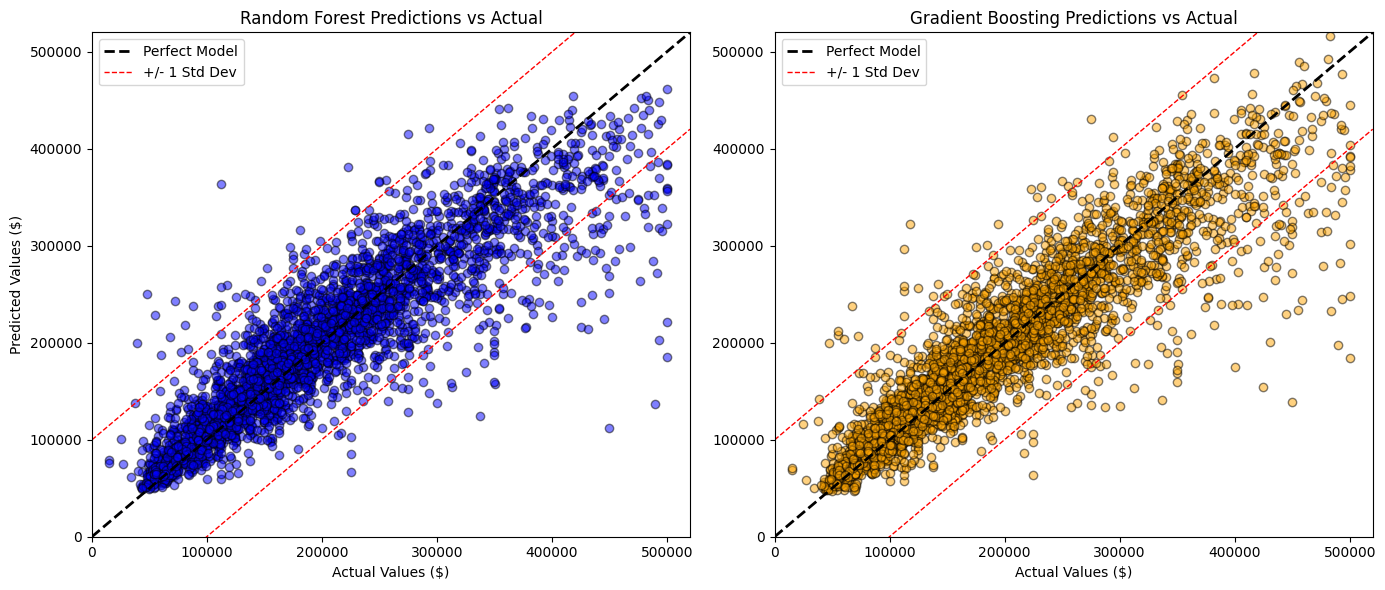

In [52]:
import matplotlib.pyplot as plt
import numpy as np

print("--- VISUALIZING MODEL PERFORMANCE ---")

# Calculate the standard deviation of the actual prices
std_y = y_test_eng.std()

# Define the minimum and maximum boundaries for our plot axes
# We add a $20,000 buffer to the max so the points don't touch the very edge of the graph
min_val = 0
max_val = y_test_eng.max() + 20000 

plt.figure(figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Random Forest
# ---------------------------------------------------------
plt.subplot(1, 2, 1)
plt.scatter(y_test_eng, eng_preds, alpha=0.5, color="blue", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values ($)")
plt.ylabel("Predicted Values ($)")
plt.legend(loc="upper left")

# ---------------------------------------------------------
# Plot 2: Gradient Boosting
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
plt.scatter(y_test_eng, tuned_gbr_preds, alpha=0.5, color="orange", ec='k')

# The "Perfect Model" diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Model")

# The +/- 1 Standard Deviation lines
plt.plot([min_val, max_val], [min_val + std_y, max_val + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([min_val, max_val], [min_val - std_y, max_val - std_y], 'r--', lw=1)

# Formatting
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("Gradient Boosting Predictions vs Actual")
plt.xlabel("Actual Values ($)")
# We can skip the ylabel here since it shares the same scale as the left plot
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

# KNN Regressor

** NEED EDIT **
Introduction to K-Nearest Neighbors (KNN) Regression
While tree-based algorithms like Random Forest and Gradient Boosting rely on constructing complex, hierarchical rules to predict housing prices, the K-Nearest Neighbors (KNN) Regressor takes a fundamentally different, geometry-based approach. KNN operates on a simple, intuitive premise: properties with similar characteristics should have similar values.

Often categorized as a "lazy learning" algorithm, KNN does not mathematically derive an underlying function or build an internal model during the training phase. Instead, it effectively memorizes the entire training dataset. When tasked with predicting the median house value for a new, unseen neighborhood, the algorithm maps the new data point into a multi-dimensional space and calculates its mathematical distance to all existing points in the training set.

The model then identifies the 'K' closest data points—its "nearest neighbors." The final price prediction is generated by averaging the target values of these specific neighbors.

To ensure the algorithm functions correctly, particularly in real estate datasets containing a mix of diverse metrics (such as single-digit income levels alongside distances measured in hundreds of thousands of meters), strict data standardization is required. Without scaling, features with massive numerical ranges would disproportionately dominate the distance calculations, blinding the model to smaller, yet highly predictive, variables. By standardizing the data and optimizing the 'K' parameter, KNN serves as a powerful, distance-based benchmark for market valuation.

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("--- 3. K-NEAREST NEIGHBORS (KNN) ---")

# 1. The Scaling Imperative
# We MUST scale our engineered data so 'Income' and 'Distance' have equal weight
scaler_eng = StandardScaler()

# Remember the golden rule: fit_transform on train, ONLY transform on test!
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)
print("Data successfully standardized for distance calculations.")

# 2. Initialize the KNN Model
# We'll start with 7 neighbors and give closer neighbors more voting power
knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1)

print("Memorizing the California housing market...")
knn_model.fit(X_train_eng_scaled, y_train_eng)

# 3. The Final Exam
knn_preds = knn_model.predict(X_test_eng_scaled)
knn_mae = mean_absolute_error(y_test_eng, knn_preds)
knn_r2 = r2_score(y_test_eng, knn_preds)

print(f"\n--- RESULTS ---")
print(f"KNN Mean Absolute Error (MAE): ${knn_mae:,.0f}")
print(f"KNN R^2 Score:                 {knn_r2:.4f}")

--- 3. K-NEAREST NEIGHBORS (KNN) ---
Data successfully standardized for distance calculations.
Memorizing the California housing market...

--- RESULTS ---
KNN Mean Absolute Error (MAE): $37,151
KNN R^2 Score:                 0.7027


# Support Vector Regression (SVR)